<a href="https://colab.research.google.com/github/charlottedawnwatson/PortfolioProjects/blob/main/Ultra_Marathons_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
zip_path = '/content/drive/MyDrive/archive (1).zip'

In [ ]:
import zipfile

# Make a folder to extract
extract_path = '/content/extracted/'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Extraction complete! Files are in:", extract_path)


Extraction complete! Files are in: /content/extracted/


In [ ]:
import os

extracted_folder = '/content/extracted/'
print(os.listdir(extracted_folder))


['TWO_CENTURIES_OF_UM_RACES.csv', 'TWO_CENTURIES_OF_UM_RACES']


In [ ]:
import pandas as pd
import os

# Path to the extracted folder
extracted_folder = '/content/extracted/'

# Full path to your CSV
csv_file = os.path.join(extracted_folder, 'TWO_CENTURIES_OF_UM_RACES.csv')

# Load CSV into a DataFrame
df = pd.read_csv(csv_file)

# Preview first 5 rows
print(df.head())

/tmp/ipykernel_58814/3709331918.py:11: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)


   Year of event Event dates           Event name Event distance/length  \
0           2018  06.01.2018  Selva Costera (CHI)                  50km   
1           2018  06.01.2018  Selva Costera (CHI)                  50km   
2           2018  06.01.2018  Selva Costera (CHI)                  50km   
3           2018  06.01.2018  Selva Costera (CHI)                  50km   
4           2018  06.01.2018  Selva Costera (CHI)                  50km   

   Event number of finishers Athlete performance        Athlete club  \
0                         22           4:51:39 h               Tnfrc   
1                         22           5:15:45 h  Roberto Echeverría   
2                         22           5:16:44 h   Puro Trail Osorno   
3                         22           5:34:13 h            Columbia   
4                         22           5:54:14 h      Baguales Trail   

  Athlete country  Athlete year of birth Athlete gender Athlete age category  \
0             CHI                 19

In [ ]:
df.head()

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
0,2018,06.01.2018,Selva Costera (CHI),50km,22,4:51:39 h,Tnfrc,CHI,1978.0,M,M35,10.286,0
1,2018,06.01.2018,Selva Costera (CHI),50km,22,5:15:45 h,Roberto Echeverría,CHI,1981.0,M,M35,9.501,1
2,2018,06.01.2018,Selva Costera (CHI),50km,22,5:16:44 h,Puro Trail Osorno,CHI,1987.0,M,M23,9.472,2
3,2018,06.01.2018,Selva Costera (CHI),50km,22,5:34:13 h,Columbia,ARG,1976.0,M,M40,8.976,3
4,2018,06.01.2018,Selva Costera (CHI),50km,22,5:54:14 h,Baguales Trail,CHI,1992.0,M,M23,8.469,4


In [ ]:
df = df.rename(columns={'Year of event': 'year',
                   'Event dates': 'event_dates',
                   'Event name': 'name',
                   'Event distance/length': 'distance',
                   'Event number of finishers': 'no_finishers',
                   'Athlete performance': 'athlete_performance',
                   'Athlete club': 'athlete_club',
                   'Athlete country': 'athlete_country',
                   'Athlete year of birth': 'athlete_year_of_birth',
                   'Athlete gender': 'athlete_gender',
                   'Athlete age category': 'athlete_age_category',
                   'Athlete average speed': 'athlete_average_speed',
                   'Athlete ID': 'athlete_id'})

In [ ]:
df = df.drop('athlete_id', axis=1)
df.head()

,year,event_dates,name,distance,no_finishers,athlete_performance,athlete_club,athlete_country,athlete_year_of_birth,athlete_gender,athlete_age_category,athlete_average_speed
0,2018,06.01.2018,Selva Costera (CHI),50km,22,4:51:39 h,Tnfrc,CHI,1978.0,M,M35,10.286
1,2018,06.01.2018,Selva Costera (CHI),50km,22,5:15:45 h,Roberto Echeverría,CHI,1981.0,M,M35,9.501
2,2018,06.01.2018,Selva Costera (CHI),50km,22,5:16:44 h,Puro Trail Osorno,CHI,1987.0,M,M23,9.472
3,2018,06.01.2018,Selva Costera (CHI),50km,22,5:34:13 h,Columbia,ARG,1976.0,M,M40,8.976
4,2018,06.01.2018,Selva Costera (CHI),50km,22,5:54:14 h,Baguales Trail,CHI,1992.0,M,M23,8.469


In [ ]:
df = df.loc[~df.duplicated()]
df.reset_index(drop=True)

,year,event_dates,name,distance,no_finishers,athlete_performance,athlete_club,athlete_country,athlete_year_of_birth,athlete_gender,athlete_age_category,athlete_average_speed
0,2018,06.01.2018,Selva Costera (CHI),50km,22,4:51:39 h,Tnfrc,CHI,1978.0,M,M35,10.286
1,2018,06.01.2018,Selva Costera (CHI),50km,22,5:15:45 h,Roberto Echeverría,CHI,1981.0,M,M35,9.501
2,2018,06.01.2018,Selva Costera (CHI),50km,22,5:16:44 h,Puro Trail Osorno,CHI,1987.0,M,M23,9.472
3,2018,06.01.2018,Selva Costera (CHI),50km,22,5:34:13 h,Columbia,ARG,1976.0,M,M40,8.976
4,2018,06.01.2018,Selva Costera (CHI),50km,22,5:54:14 h,Baguales Trail,CHI,1992.0,M,M23,8.469
...,...,...,...,...,...,...,...,...,...,...,...,...
7415977,1995,00.00.1995,La SainteLyon 65 km (FRA),65km,2,4:33:20 h,NaN,FRA,NaN,M,NaN,14268.0
7415978,1995,00.00.1995,La SainteLyon 65 km (FRA),65km,2,6:05:15 h,NaN,FRA,NaN,F,NaN,10678.0
7415979,1995,00.00.1995,Szombathely 24 hours running Race (HUN),24h,3,241.000 km,*Budapest,HUN,1950.0,M,M40,10042.0
7415980,1995,00.00.1995,Szombathely 24 hours running Race (HUN),24h,3,228.000 km,*Szeged,HUN,1959.0,M,M35,9500.0


In [ ]:
df['athlete_age'] = df['athlete_age_category'].str.replace('[MWF]', '', regex=True)

In [ ]:
df.head()

,year,event_dates,name,distance,no_finishers,athlete_performance,athlete_club,athlete_country,athlete_year_of_birth,athlete_gender,athlete_age_category,athlete_average_speed,athlete_age
0,2018,06.01.2018,Selva Costera (CHI),50km,22,4:51:39 h,Tnfrc,CHI,1978.0,M,M35,10.286,35
1,2018,06.01.2018,Selva Costera (CHI),50km,22,5:15:45 h,Roberto Echeverría,CHI,1981.0,M,M35,9.501,35
2,2018,06.01.2018,Selva Costera (CHI),50km,22,5:16:44 h,Puro Trail Osorno,CHI,1987.0,M,M23,9.472,23
3,2018,06.01.2018,Selva Costera (CHI),50km,22,5:34:13 h,Columbia,ARG,1976.0,M,M40,8.976,40
4,2018,06.01.2018,Selva Costera (CHI),50km,22,5:54:14 h,Baguales Trail,CHI,1992.0,M,M23,8.469,23


In [ ]:
df['age_under'] = 'N'



In [ ]:
import numpy as np

df['age_under'] = np.where(
    df['athlete_age'].str.startswith('U', na=False),
    'Y',  # if condition True
    'N'   # if condition False
)

In [ ]:
df = df.drop('athlete_age_category', axis=1)

In [ ]:
df['athlete_age'] = df['athlete_age'].str.replace('U', '', regex=False)

In [ ]:
df['athlete_age'] = df['athlete_age'].astype('Int64')

In [ ]:
df.isnull().sum()

,0
year,0
event_dates,0
name,0
distance,1052
no_finishers,0
athlete_performance,2
athlete_club,2789866
athlete_country,3
athlete_year_of_birth,559750
athlete_gender,7


In [ ]:
df = df.dropna(subset=["athlete_gender"])

In [ ]:
df.isnull().sum()

,0
year,0
event_dates,0
name,0
distance,1052
no_finishers,0
athlete_performance,0
athlete_club,2789861
athlete_country,1
athlete_year_of_birth,559746
athlete_gender,0


In [ ]:
df["distance"].str.contains('km', case=False, na=False).value_counts()

,count
distance,
True,6130591
False,1285384


In [ ]:
df = df[df["distance"].str.contains('km', case=False, na=False)]
df

,year,event_dates,name,distance,no_finishers,athlete_performance,athlete_club,athlete_country,athlete_year_of_birth,athlete_gender,athlete_average_speed,athlete_age,age_under
0,2018,06.01.2018,Selva Costera (CHI),50km,22,4:51:39 h,Tnfrc,CHI,1978.0,M,10.286,35,N
1,2018,06.01.2018,Selva Costera (CHI),50km,22,5:15:45 h,Roberto Echeverría,CHI,1981.0,M,9.501,35,N
2,2018,06.01.2018,Selva Costera (CHI),50km,22,5:16:44 h,Puro Trail Osorno,CHI,1987.0,M,9.472,23,N
3,2018,06.01.2018,Selva Costera (CHI),50km,22,5:34:13 h,Columbia,ARG,1976.0,M,8.976,40,N
4,2018,06.01.2018,Selva Costera (CHI),50km,22,5:54:14 h,Baguales Trail,CHI,1992.0,M,8.469,23,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7461093,1995,07.01.1995,Centenary Lakes 50 Km Track Run (AUS),50km,6,5:58:16 h,*QLD,AUS,1938.0,F,8374.0,55,N
7461186,1995,00.00.1995,Supermaraton Zagreb-Cazma (CRO),61.3km,2,3:49:48 h,NaN,CRO,1965.0,M,16005.0,23,N
7461187,1995,00.00.1995,Supermaraton Zagreb-Cazma (CRO),61.3km,2,4:35:57 h,NaN,HUN,1962.0,F,13329.0,23,N
7461190,1995,00.00.1995,La SainteLyon 65 km (FRA),65km,2,4:33:20 h,NaN,FRA,NaN,M,14268.0,<NA>,N


In [ ]:
df["distance"] = df["distance"].str.replace(" ", "", regex=False)

In [ ]:
df["distance"] = df["distance"].str.lower()


In [ ]:
df["distance_km"] = df["distance"].str.extract(r"(\d+\.?\d*)km")

In [ ]:
df["race_stages"] = df["distance"].str.extract(r"(\d+\.?\d*)Etappen")

In [ ]:
df["distance_km"] = df["distance_km"].astype(float)

In [ ]:
df["race_stages"] = df["race_stages"].astype(float)

In [ ]:
df["athlete_average_speed"].str.contains(":", na=False).value_counts()

,count
athlete_average_speed,
False,6130110
True,481


In [ ]:
df["athlete_average_speed"].str.contains("[A-Za-z]", na=False).value_counts()

,count
athlete_average_speed,
False,6130591


In [ ]:
mask = df["athlete_average_speed"].str.contains(":", na=False)
df.loc[mask, "athlete_average_speed"]

,athlete_average_speed
1169473,06:03:22
1169474,06:37:13
1169475,06:49:03
1169476,06:58:14
1169477,07:05:48
...,...
6773696,08:46:33
6773697,09:08:20
6773698,09:27:18
6773699,09:27:40


In [ ]:
df.loc[mask, "time"] = pd.to_timedelta(df.loc[mask, "athlete_average_speed"])

In [ ]:
df[df["time"].notna()]

,year,event_dates,name,distance,no_finishers,athlete_performance,athlete_club,athlete_country,athlete_year_of_birth,athlete_gender,athlete_average_speed,athlete_age,age_under,distance_km,race_stages,time
1169473,2016,05.11.2016,Halden Ultraintervall 8x10km (NOR),80km,11,6:03:22 h,Romerike Ultraløperklubb,NOR,1973.0,M,06:03:22,40,N,80.0,NaN,0 days 06:03:22
1169474,2016,05.11.2016,Halden Ultraintervall 8x10km (NOR),80km,11,6:37:13 h,2150 Kondisjonsidrettslag,NOR,1983.0,M,06:37:13,23,N,80.0,NaN,0 days 06:37:13
1169475,2016,05.11.2016,Halden Ultraintervall 8x10km (NOR),80km,11,6:49:03 h,Romerike Ultraløperklubb,NOR,1971.0,M,06:49:03,45,N,80.0,NaN,0 days 06:49:03
1169476,2016,05.11.2016,Halden Ultraintervall 8x10km (NOR),80km,11,6:58:14 h,Halden Tannhelsesenter AS,NOR,1979.0,M,06:58:14,35,N,80.0,NaN,0 days 06:58:14
1169477,2016,05.11.2016,Halden Ultraintervall 8x10km (NOR),80km,11,7:05:48 h,Fredrikstad Triatlonklubb,NOR,1976.0,M,07:05:48,35,N,80.0,NaN,0 days 07:05:48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6773696,2015,07.11.2015,Halden Ultraintervall 8x10km (NOR),80km,21,8:46:33 h,Team Ekstrøm,NOR,1966.0,F,08:46:33,45,N,80.0,NaN,0 days 08:46:33
6773697,2015,07.11.2015,Halden Ultraintervall 8x10km (NOR),80km,21,9:08:20 h,Romerike Ultraløperklubb,NOR,1953.0,M,09:08:20,60,N,80.0,NaN,0 days 09:08:20
6773698,2015,07.11.2015,Halden Ultraintervall 8x10km (NOR),80km,21,9:27:18 h,Blodsmak SK,NOR,1970.0,M,09:27:18,40,N,80.0,NaN,0 days 09:27:18
6773699,2015,07.11.2015,Halden Ultraintervall 8x10km (NOR),80km,21,9:27:40 h,Blodsmak SK,NOR,1963.0,M,09:27:40,50,N,80.0,NaN,0 days 09:27:40


In [ ]:
df["hours_num"] = df["time"].dt.total_seconds() / 3600

In [ ]:
df["time"] = pd.to_timedelta(df["athlete_performance"])



In [ ]:
df["hours_num"] = df["time"].dt.total_seconds() / 3600

In [ ]:
df["speed"] = df["distance_km"] / df["hours_num"]

In [ ]:
df["speed"] = df["speed"].fillna(285/df["hours_num"])

In [ ]:
df["race_stages"] = df["distance"].str.extract(r"(\d+\.?\d*)etappen")

In [ ]:
df["race_stages"] = df["distance"].str.extract(r"(\d+\.?\d*)stages")

In [ ]:
df["race_stages"] = df["distance"].str.extract(r"(\d+\.?\d*)x")

In [ ]:
df["race_stages"] = df["distance"].str.extract(r"470km/(\d+\.?\d*)")

In [ ]:
df[df["distance"]=="4x52km"]

,year,event_dates,name,distance,no_finishers,athlete_performance,athlete_club,athlete_country,athlete_year_of_birth,athlete_gender,athlete_average_speed,athlete_age,age_under,distance_km,race_stages,time,hours_num,speed
2103612,2019,04.-07.07.2019,Notchview Ultra Quadzilla Ultra (USA),4x52km,4,38:31:27 h,"*New Hartford, CT",USA,1977.0,M,0,40,N,52.0,NaN,1 days 14:31:27,38.524167,1.349802
2103613,2019,04.-07.07.2019,Notchview Ultra Quadzilla Ultra (USA),4x52km,4,47:11:01 h,"*New Hartford, NY",USA,1996.0,F,0,23,Y,52.0,NaN,1 days 23:11:01,47.183611,1.102078
2103614,2019,04.-07.07.2019,Notchview Ultra Quadzilla Ultra (USA),4x52km,4,2d 12:44:40 h,"*Rochester, NY",USA,1964.0,M,0,50,N,52.0,NaN,2 days 12:44:40,60.744444,0.856045
2103615,2019,04.-07.07.2019,Notchview Ultra Quadzilla Ultra (USA),4x52km,4,2d 20:49:30 h,"*Worcester, MA",USA,1991.0,M,0,23,N,52.0,NaN,2 days 20:49:30,68.825000,0.755539


In [ ]:
onerace = df[df["race_stages"].isna()]

In [ ]:
onerace = onerace.drop(columns=["time", "race_stages", "athlete_average_speed"])

In [ ]:
completed = onerace[np.isfinite(onerace["speed"])]

In [ ]:
from pandas.core import groupby
completed.groupby("athlete_gender")["speed"].describe()

,count,mean,std,min,25%,50%,75%,max
athlete_gender,,,,,,,,
F,1103495.0,6.990565,1.966437,0.192135,5.556242,6.941320,8.303732,49.792531
M,5027004.0,7.516528,2.287448,0.501892,5.832573,7.408017,8.946767,28.301887
X,22.0,7.416663,1.610854,4.912418,6.054625,7.583528,8.565377,10.757829


In [ ]:
completed.sort_values("speed", ascending=False)

,year,event_dates,name,distance,no_finishers,athlete_performance,athlete_club,athlete_country,athlete_year_of_birth,athlete_gender,athlete_age,age_under,distance_km,hours_num,speed
5516610,2012,10.11.2012,Pass Mountain 50 km Race (USA),50km,41,1:00:15 h,"*Gilbert, AZ",USA,1974.0,F,35,N,50.0,1.004167,49.792531
6929868,1980,31.05.1980,Bílovecká 50 (CZE),100km,15,3:32:00 h,Sokol Zabovresky,CZE,1952.0,M,23,N,100.0,3.533333,28.301887
6929869,1980,31.05.1980,Bílovecká 50 (CZE),100km,15,3:36:00 h,Slavoj Rychvald,CZE,1952.0,M,23,N,100.0,3.600000,27.777778
6929870,1980,31.05.1980,Bílovecká 50 (CZE),100km,15,3:39:00 h,TJ Vitkovice,CZE,1957.0,M,23,Y,100.0,3.650000,27.397260
6929871,1980,31.05.1980,Bílovecká 50 (CZE),100km,15,3:47:00 h,Slez.Fryd.-Mistek,CZE,1947.0,M,23,N,100.0,3.783333,26.431718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2103615,2019,04.-07.07.2019,Notchview Ultra Quadzilla Ultra (USA),4x52km,4,2d 20:49:30 h,"*Worcester, MA",USA,1991.0,M,23,N,52.0,68.825000,0.755539
5704201,2013,16.-19.05.2013,3 Days at the Fair 50km Race (USA),50km,15,2d 23:18:42 h,*PA,USA,1961.0,M,50,N,50.0,71.311667,0.701148
3942185,2001,22.04.2001,"100km Meisterschaft von Russland, Chernogolovk...",50km,36,3d 11:21:08 h,*Glasov Udmurtia,RUS,1977.0,M,23,N,50.0,83.352222,0.599864
3016630,2021,16.10.2021,The BIG 50 (USA),50km,34,4d 03:37:23 h,"*Columbus, GA",USA,1999.0,M,23,Y,50.0,99.623056,0.501892


In [ ]:
completed[completed["speed"]>20].value_counts()

year  event_dates  name                               distance  no_finishers  athlete_performance  athlete_club        athlete_country  athlete_year_of_birth  athlete_gender  athlete_age  age_under  distance_km  hours_num  speed    
1975  02.06.1975   60 km Burgdorf (SUI)               60km      8             2:46:02 h            *Herzogenbuchsee    SUI              1938.0                 M               35           N          60.0         2.767222   21.682393    1
1980  31.05.1980   Bílovecká 50 (CZE)                 100km     15            3:32:00 h            Sokol Zabovresky    CZE              1952.0                 M               23           N          100.0        3.533333   28.301887    1
                                                                              3:36:00 h            Slavoj Rychvald     CZE              1952.0                 M               23           N          100.0        3.600000   27.777778    1
                                                                              3:39:00 h            TJ Vitkovice        CZE              1957.0                 M               23           Y          100.0        3.650000   27.397260    1
                                                                              3:47:00 h            Slez.Fryd.-Mistek   CZE              1947.0                 M               23           N          100.0        3.783333   26.431718    1
                                                                              3:48:00 h            Lokomot. Olomouc    CZE              1946.0                 M               23           N          100.0        3.800000   26.315789    1
                                                                              3:53:00 h            Slavoj Bruntal      CZE              1941.0                 M               35           N          100.0        3.883333   25.751073    1
                                                                              4:03:00 h            Universita Olomouc  CZE              1952.0                 M               23           N          100.0        4.050000   24.691358    1
                                                                              4:13:00 h            Lokomotiva Brno     CZE              1937.0                 M               40           N          100.0        4.216667   23.715415    1
                                                                              4:14:00 h            Spartak Bilovec     CZE              1952.0                 M               23           N          100.0        4.233333   23.622047    1
                                                                              4:17:00 h            Sokol Kobeřice      CZE              1936.0                 M               40           N          100.0        4.283333   23.346304    1
                                                                              4:30:00 h            Bílovec             CZE              1961.0                 M               23           Y          100.0        4.500000   22.222222    1
                                                                              4:51:00 h            Liga 100 Olomouc    CZE              1941.0                 M               35           N          100.0        4.850000   20.618557    1
                                                                              4:52:00 h            TJ Vitkovice        CZE              1937.0                 M               40           N          100.0        4.866667   20.547945    1
2012  10.11.2012   Pass Mountain 50 km Race (USA)     50km      41            1:00:15 h            *Gilbert, AZ        USA              1974.0                 F               35           N          50.0         1.004167   49.792531    1
2013  10.11.2013   Trail des 2 Provinces 45 km (BEL)  45km      35            2:07:40 h            RCB                 FRA              1992.0                 M               23           Y        

In [ ]:
completed = completed[(completed["name"]!="Bílovecká 50 (CZE)")]

In [ ]:
completed = completed[(completed["name"]!="Pass Mountain 50 km Race (USA)")]

In [ ]:
completed = completed[(completed["speed"]<=20)]

In [ ]:
completed.groupby("athlete_gender")["speed"].describe()

,count,mean,std,min,25%,50%,75%,max
athlete_gender,,,,,,,,
F,1103337.0,6.990455,1.966094,0.192135,5.556032,6.941231,8.303732,17.673049
M,5026612.0,7.516395,2.287218,0.501892,5.832415,7.407936,8.946722,19.713425
X,22.0,7.416663,1.610854,4.912418,6.054625,7.583528,8.565377,10.757829


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


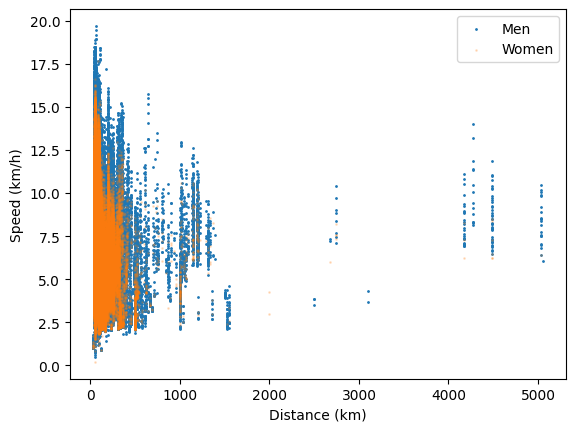

In [ ]:
sample = completed

plt.scatter(
    sample.loc[sample["athlete_gender"]=="M", "distance_km"],
    sample.loc[sample["athlete_gender"]=="M", "speed"],
               s=1,
               alpha=1,
               label="Men"
)

plt.scatter(
    sample.loc[sample["athlete_gender"]=="F", "distance_km"],
    sample.loc[sample["athlete_gender"]=="F", "speed"],
    s=1,
    alpha=0.2,
    label="Women"
)

plt.xlabel("Distance (km)")
plt.ylabel("Speed (km/h)")
plt.legend()
plt.show()